# PRT-DeepONet — Velocity variant (load & run)

Predicts the divergence-free velocity field `(ux, uy)` (λ=10) from a pore geometry.

**Branch CNN** ← geometry + MIS map (local pore size) + UPRM map (non-local connectivity).  
**Branch FNN** ← Reynolds number.  
**Trunk** ← `(x, y)`, squared wall distance `d_w²`, harmonic pressure-gradient priors `(∂ₓP, ∂ᵧP)`.

In [1]:
# ===============================
# 1) Imports & Global Setup
# ===============================
import os
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from collections import deque
from itertools import product
from scipy.ndimage import distance_transform_edt, binary_dilation

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('DEVICE:', DEVICE)

# Grid
NX, NY = 64, 148
L = NX * NY

# --- Input-feature normalization constants (fixed at training time) ---
UPRM_MU, UPRM_SD = 2.4316839948181954, 1.9931210222984472   # upstream-constrained pore radius map (UPRM)
MIS_MU,  MIS_SD  = 5.161643981933594,  3.299696683883667    # maximum-inscribed-sphere (MIS) map
DW2_MIN, DW2_MAX = 1.0, 784.0                                # squared wall distance d_w^2 range

# --- Velocity output denormalization (model predicts standardized velocity) ---
# physical velocity = u_norm * SD + MU
VEL_MU_U, VEL_SD_U = 0.00023968351888470352, 0.0005056853988207877
VEL_MU_V, VEL_SD_V = 6.503713052552484e-07,  0.00029989489121362567

# --- Reynolds-number branch conditions, precomputed for the bundled domain ---
# RE_B2 : normalized Reynolds number fed to the branch FNN (model input)
# RE    : physical Reynolds number of each condition (for display) - three flow rates
RE_B2 = {0: 0.009110829792916775, 1: 0.02172919735312462, 2: 0.04727563634514809}
RE    = {0: 0.042043, 1: 0.084424, 2: 0.170226}

DEVICE: cuda


In [2]:
MODEL_PATH  = '../parameters/Velocity.pt'
GVNET_PATH  = '../parameters/Pressure_component_UNet.pt'
DOMAIN_PATH = '../examples/Domain_Velocity.npz'
for p in (MODEL_PATH, GVNET_PATH, DOMAIN_PATH): assert os.path.exists(p), f'Not found: {p}'

In [3]:
# ===============================
# Geometry features for the velocity variant
#   UPRM : upstream-constrained pore radius map (non-local, path-dependent connectivity)
#   MIS  : maximum-inscribed-sphere map (local pore size)
#   d_w^2: squared wall distance
# ===============================
import heapq

def uprm_map(m):
    """Upstream-constrained pore radius map (a.k.a. flow-neck): the largest bottleneck
    radius reachable from the inlet along the widest path (min over the path, max over paths)."""
    H, W = m.shape; void = (m > 0)
    e = distance_transform_edt(void).astype(np.float32)
    acc = np.zeros_like(e); vis = np.zeros_like(void, bool); hp = []
    for y in range(H):
        if void[y, 0]:
            acc[y, 0] = float(e[y, 0]); heapq.heappush(hp, (-float(e[y, 0]), y, 0))
    while hp:
        nv, y, x = heapq.heappop(hp); cur = -nv
        if vis[y, x]: continue
        vis[y, x] = True
        for dy, dx in [(-1,0),(1,0),(0,-1),(0,1)]:
            yy, xx = y+dy, x+dx
            if 0 <= yy < H and 0 <= xx < W and void[yy, xx]:
                cand = min(cur, float(e[yy, xx]))
                if cand > acc[yy, xx]:
                    acc[yy, xx] = cand; heapq.heappush(hp, (-cand, yy, xx))
    acc *= void.astype(np.float32)
    return acc.astype(np.float32)

BUF = 10
def _local_thickness(m, r_step=0.5):
    pore = (m > 0); edt = distance_transform_edt(pore).astype(np.float32); rmax = float(edt.max())
    if rmax <= 0: return np.zeros_like(edt)
    res = np.zeros_like(edt)
    for r in np.arange(rmax, 0, -r_step):
        centers = pore & (edt >= r - 1e-6)
        if not centers.any(): continue
        rr = int(np.ceil(r)); yy, xx = np.ogrid[-rr:rr+1, -rr:rr+1]; disk = (xx*xx + yy*yy) <= r*r
        painted = binary_dilation(centers, structure=disk) & pore
        newly = painted & (res == 0); res[newly] = r
    res[~pore] = 0.0; return res.astype(np.float32)

def _sphere_paint(m, lt, buf=BUF):
    H, W = m.shape; pore = (m > 0)
    left = np.zeros((H,W), bool); left[:, :buf] = True
    right = np.zeros((H,W), bool); right[:, W-buf:] = True
    full = np.zeros((H,W), np.float32); full[:, buf:W-buf] = lt
    seed = np.zeros((H,W), np.float32); seed[:, buf:W-buf] = lt
    for r in np.unique(seed[seed > 0])[::-1]:
        ce = seed >= r - 1e-6; rr = int(np.ceil(r)); yy, xx = np.ogrid[-rr:rr+1, -rr:rr+1]; dk = (xx*xx + yy*yy) <= r*r
        pt = binary_dilation(ce, structure=dk)
        for reg in (left, right):
            up = pt & reg & (full < r); full[up] = r
    return full, pore, (left | right)

def mis_map(m, buf=BUF):
    """Maximum-inscribed-sphere map (local pore size), buffer-filled at the inlet/outlet."""
    lt = _local_thickness(m[:, buf:m.shape[1]-buf], 0.5)
    full, pore, bufreg = _sphere_paint(m, lt, buf)
    vmin = float(lt[lt > 0].min()) if (lt > 0).any() else 0.0
    bp = pore & bufreg & (full <= 0); full[bp] = vmin; full[m <= 0] = 0.0
    return full.astype(np.float32)

def dw2_map(m):
    """Squared wall distance d_w^2, scaled to [0,1]."""
    pore = (m > 0); e = distance_transform_edt(pore).astype(np.float32); f2 = e*e
    o = np.zeros_like(f2); o[pore] = np.clip((f2[pore]-DW2_MIN)/(DW2_MAX-DW2_MIN), 0, 1)
    return o.astype(np.float32)

In [4]:
# ===============================
# Pressure-component U-Net  (predicts harmonic pressure-gradient priors: dP/dx, dP/dy)
# ===============================
N_BLOCKS, BASE_CH, DEPTH, DROPOUT = 4, 64, 6, 0.1
class ConvBlock(nn.Module):
    def __init__(self, ci, co, p=DROPOUT):
        super().__init__(); self.conv = nn.Conv2d(ci, co, 3, padding=1)
        self.drop = nn.Dropout2d(p); self.bn = nn.BatchNorm2d(co)
    def forward(self, x): return self.bn(self.drop(F.relu(self.conv(x))))
class Container(nn.Module):
    def __init__(self, ci, co, n=N_BLOCKS, p=DROPOUT):
        super().__init__()
        self.net = nn.Sequential(*([ConvBlock(ci, co, p)] + [ConvBlock(co, co, p) for _ in range(n-1)]))
    def forward(self, x): return self.net(x)
class PressureComponentUNet(nn.Module):
    def __init__(self, in_ch=1, out_ch=2, base=BASE_CH, depth=DEPTH, n=N_BLOCKS, p=DROPOUT):
        super().__init__(); self.depth = depth; self.enc = nn.ModuleList(); c = in_ch
        for _ in range(depth): self.enc.append(Container(c, base, n, p)); c = base
        self.pool = nn.MaxPool2d(2); self.bottleneck = Container(base, base, n, p)
        self.up = nn.ModuleList([nn.ConvTranspose2d(base, base, 2, stride=2) for _ in range(depth)])
        self.dec = nn.ModuleList([Container(base*2, base, n, p) for _ in range(depth)])
        self.head_container = Container(base, base, n, p); self.head = nn.Conv2d(base, out_ch, 1)
    def forward(self, x):
        sk = []
        for d in range(self.depth): x = self.enc[d](x); sk.append(x); x = self.pool(x)
        x = self.bottleneck(x)
        for d in range(self.depth):
            k = sk[self.depth-1-d]; x = self.up[d](x)
            dh = k.shape[-2]-x.shape[-2]; dw = k.shape[-1]-x.shape[-1]
            if dh or dw: x = F.pad(x, [dw//2, dw-dw//2, dh//2, dh-dh//2])
            x = torch.cat([x, k], 1); x = self.dec[d](x)
        return self.head(self.head_container(x))

In [5]:
# ===============================
# Velocity DeepONet  (branch CNN [mask, UPRM, MIS] | branch FNN [Re] | trunk [x,y,dPx,dPy,d_w^2])
# ===============================
class CustomCNN(nn.Module):
    def __init__(self, in_channels, out_dim=128, num_blocks=5):
        super().__init__(); ch = [in_channels,16,32,64,128,256,512][:num_blocks+1]; layers = []
        for i in range(num_blocks): layers += [nn.Conv2d(ch[i], ch[i+1], 3, 1, 1), nn.SiLU(), nn.AvgPool2d(2)]
        self.features = nn.Sequential(*layers); h, w = NX, NY
        for _ in range(num_blocks): h //= 2; w //= 2
        self.fc = nn.Linear(ch[num_blocks]*h*w, out_dim)
    def forward(self, x): x = self.features(x); return self.fc(x.view(x.size(0), -1))
class ScalarMLP(nn.Module):
    def __init__(self, in_dim=1, out_dim=128, hidden=128, layers=3):
        super().__init__(); m = [nn.Linear(in_dim, hidden), nn.SiLU()]
        for _ in range(layers-2): m += [nn.Linear(hidden, hidden), nn.SiLU()]
        m += [nn.Linear(hidden, out_dim)]; self.net = nn.Sequential(*m)
    def forward(self, x): return self.net(x)
def make_trunk(in_dim=5, out_dim=128, layers=8, width=128):
    m = [nn.Linear(in_dim, width), nn.SiLU()]
    for _ in range(layers-2): m += [nn.Linear(width, width), nn.SiLU()]
    m += [nn.Linear(width, out_dim)]; return nn.Sequential(*m)
class VelocityDeepONet(nn.Module):
    def __init__(self, b1_ch=3, out_dim=128, n_out=2):
        super().__init__(); self.branch1 = CustomCNN(b1_ch, out_dim, num_blocks=5)
        self.branch2 = ScalarMLP(1, out_dim, 128, 3); self.trunk = make_trunk(5, out_dim, 8, 128)
        self.bias = nn.Parameter(torch.zeros(n_out)); self.nx, self.ny = NX, NY
        self.n_out = n_out; self.half = out_dim // n_out
    def forward(self, b1, b2, tr):
        N, Lc, D = tr.shape; t = self.trunk(tr.reshape(-1, D)).view(N, Lc, -1)
        b1o = self.branch1(b1).unsqueeze(1); b2o = self.branch2(b2).unsqueeze(1)
        prod = (b1o*b2o*t).view(N, Lc, self.n_out, self.half).sum(-1)
        return (prod + self.bias).view(N, self.nx, self.ny, self.n_out)

In [6]:
# --- Load gvnet ---
def _robust_load(path):
    try: st = torch.load(path, map_location=DEVICE)
    except Exception: st = torch.load(path, map_location=DEVICE, weights_only=False)
    return st.get('state_dict', st) if isinstance(st, dict) else st
gvnet = PressureComponentUNet(1, 2).to(DEVICE)
_m, _u = gvnet.load_state_dict(_robust_load('../parameters/Pressure_component_UNet.pt'), strict=False)
gvnet.eval(); print('loaded ../parameters/Pressure_component_UNet.pt | missing', len(_m), 'unexpected', len(_u))

# --- Load velmodel ---
def _robust_load(path):
    try: st = torch.load(path, map_location=DEVICE)
    except Exception: st = torch.load(path, map_location=DEVICE, weights_only=False)
    return st.get('state_dict', st) if isinstance(st, dict) else st
velmodel = VelocityDeepONet(3, 128, 2).to(DEVICE)
_m, _u = velmodel.load_state_dict(_robust_load('../parameters/Velocity.pt'), strict=False)
velmodel.eval(); print('loaded ../parameters/Velocity.pt | missing', len(_m), 'unexpected', len(_u))

loaded ../parameters/Pressure_component_UNet.pt | missing 0 unexpected 0
loaded ../parameters/Velocity.pt | missing 0 unexpected 0


In [7]:
# ===============================
# Velocity inference helper:  mask -> [UPRM, MIS, d_w^2, dPx, dPy] -> velocity (ux, uy)
# ===============================
x_coords = np.arange(NX, dtype=np.float32) / (NX - 1)
y_coords = np.arange(NY, dtype=np.float32) / (NY - 1)
Xg, Yg = np.meshgrid(x_coords, y_coords, indexing='ij')
XY = torch.tensor(np.stack([Xg.reshape(-1), Yg.reshape(-1)], axis=1), dtype=torch.float32).to(DEVICE)

@torch.no_grad()
def predict_velocity(m_bin, re_b2):
    """m_bin: (NX,NY) {0,1}; re_b2: scalar Reynolds condition. Returns (NX,NY,2) physical velocity.
    The velocity model uses the BLOCK_TOP_BOTTOM convention: the top/bottom wall rows are zeroed
    before feature/velocity computation."""
    m = m_bin.astype(np.float32).copy()
    m[0, :] = 0.0; m[-1, :] = 0.0                 # BLOCK_TOP_BOTTOM (velocity convention)
    pore = (m == 1)
    uprm_z = ((uprm_map(m) - UPRM_MU) / UPRM_SD).astype(np.float32)
    mis_z  = ((mis_map(m)  - MIS_MU)  / MIS_SD ).astype(np.float32)
    dw2    = dw2_map(m)
    mask_t = torch.from_numpy(m).to(DEVICE)
    dP = gvnet((mask_t == 1).float().view(1, 1, NX, NY))[0]        # (2,NX,NY): dPx, dPy
    pm = (mask_t == 1); Z = torch.zeros((), dtype=dP.dtype, device=DEVICE)
    gx = torch.where(pm, dP[0], Z).reshape(-1); gy = torch.where(pm, dP[1], Z).reshape(-1)
    b1 = torch.stack([mask_t, torch.from_numpy(uprm_z).to(DEVICE), torch.from_numpy(mis_z).to(DEVICE)]).unsqueeze(0)
    tr = torch.empty((1, L, 5), device=DEVICE)
    tr[0,:,0] = XY[:,0]; tr[0,:,1] = XY[:,1]; tr[0,:,2] = gx; tr[0,:,3] = gy
    tr[0,:,4] = torch.from_numpy(dw2).reshape(-1).to(DEVICE)
    b2 = torch.tensor([[float(re_b2)]], dtype=torch.float32, device=DEVICE)
    uv = velmodel(b1, b2, tr)[0]                                    # (NX,NY,2), standardized
    # denormalize to physical velocity
    ux = uv[..., 0] * VEL_SD_U + VEL_MU_U
    uy = uv[..., 1] * VEL_SD_V + VEL_MU_V
    return torch.stack([ux, uy], dim=-1)                            # (NX,NY,2), physical

In [8]:
# ===============================
# Run: predict velocity for the 3 Reynolds (pressure-drop) conditions of the domain
# ===============================
arr = np.load(DOMAIN_PATH)
m_flat = arr['m'] if 'm' in arr.files else arr[arr.files[0]]
m_bin = (m_flat.reshape(NX, NY) > 0.5).astype(np.int32)

results = {}
for vg in (0, 1, 2):
    uv = predict_velocity(m_bin, RE_B2[vg]).cpu().numpy()   # (NX,NY,2)
    results[vg] = uv
    print(f'condition {vg} (Re={RE[vg]:.4f}): velocity shape {uv.shape}')

condition 0 (Re=0.0420): velocity shape (64, 148, 2)
condition 1 (Re=0.0844): velocity shape (64, 148, 2)
condition 2 (Re=0.1702): velocity shape (64, 148, 2)


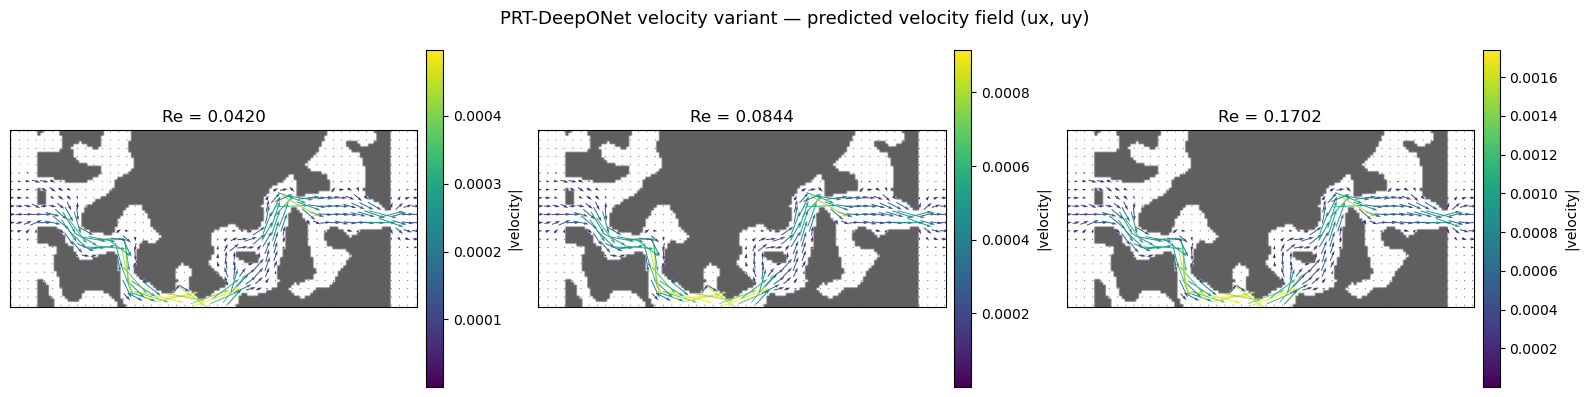

In [9]:
# ===============================
# Visualization: velocity VECTOR field for the 3 Reynolds conditions
#   arrows = (ux, uy) colored by |velocity|;  solid grains shown in gray
# ===============================
roi = (m_bin == 1); solid = ~roi
Yg_i, Xg_i = np.mgrid[0:NX, 0:NY]        # y=row (NX), x=col (NY); flow is left->right
step = 3                                 # arrow subsampling for legibility
fig, ax = plt.subplots(1, 3, figsize=(16, 4))
for c, vg in enumerate((0, 1, 2)):
    uv = results[vg]; u = uv[...,0].copy(); v = uv[...,1].copy()
    mag = np.sqrt(u**2 + v**2)
    u[solid] = np.nan; v[solid] = np.nan  # no arrows inside grains
    grain = np.ma.masked_where(~solid, np.ones_like(mag))
    ax[c].imshow(grain, origin='lower', cmap='gray_r', vmin=0, vmax=1.6)   # solid = gray
    xs = slice(None, None, step)
    q = ax[c].quiver(Xg_i[xs, xs], Yg_i[xs, xs], u[xs, xs], v[xs, xs], mag[xs, xs],
                     cmap='viridis', angles='xy', pivot='mid')
    plt.colorbar(q, ax=ax[c], fraction=0.046, pad=0.02, label='|velocity|')
    ax[c].set_title(f'Re = {RE[vg]:.4f}')
    ax[c].set_xlim(-0.5, NY-0.5); ax[c].set_ylim(-0.5, NX-0.5)
    ax[c].set_xticks([]); ax[c].set_yticks([]); ax[c].set_aspect('equal')
fig.suptitle('PRT-DeepONet velocity variant — predicted velocity field (ux, uy)', fontsize=13)
plt.tight_layout(); plt.show()